# Global Health and Life Expectancy Analysis: Descriptive Insights for 2015
## First Notebook: Introduction

Over the last decades, global health has improved dramatically: populations live longer, access to medical services has expanded, and vaccination programs have reached unprecedented coverage. Yet these advances have not benefited all nations equally. Many countries continue to face high mortality rates, limited immunization uptake, and economic constraints — making life expectancy a powerful lens through which to understand broader socioeconomic disparities.

This notebook draws on a clean, ready-to-analyze dataset compiled by the World Health Organization and the United Nations, covering 179 countries between 2000 and 2015. **For the purpose of this notebook, the analysis focuses exclusively on the year 2015**, providing a cross-sectional snapshot of global health outcomes across countries. The dataset includes 21 variables capturing essential dimensions of population health, including mortality patterns, immunization coverage, economic conditions, and education levels.

Rather than exploring multiple unrelated questions, this project focuses on one overarching research question that captures the complexity of global health while supporting a rich suite of descriptive analyses:

**How does a country’s level of economic development influence its key health indicators—such as life expectancy, mortality, BMI, and education—in 2015?**

This question enables a broad range of non-predictive analyses and extensive visualizations. It also guides the structure of the notebook, from initial descriptive statistics to cross-country comparisons by development level and multivariate descriptive patterns across key health dimensions.

Through these descriptive insights and visual explorations, this notebook aims to illuminate how health outcomes differ across countries at a given point in time, highlighting persistent disparities despite significant global progress in population health.

**Author:** J-F Jutras  
**Date:** December 2025  
**Dataset:** Life Expectancy — WHO and United Nations (Kaggle)


## 1.1-Data Loading and Overview

The dataset is retrieved directly from Kaggle using the kagglehub library. This ensures the analysis remains reproducible and uses the latest available version.

In [1]:
import pandas as pd
import os
import kagglehub

#Download latest version of the dataset
path = kagglehub.dataset_download("lashagoch/life-expectancy-who-updated")

#Define dataset path
dataset_dir = "/kaggle/input/life-expectancy-who-updated"
csv_path = os.path.join(dataset_dir, "Life-Expectancy-Data-Updated.csv")

#Load full dataset
df = pd.read_csv(csv_path)

#Keep only year 2015
df = df[df["Year"] == 2015].reset_index(drop=True)

#Basic checks
print("Shape after filtering (2015 only):", df.shape)
display(df.head())
display(df.tail())


Shape after filtering (2015 only): (179, 21)


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,Russian Federation,Rest of Europe,2015,6.6,8.2,223.0000,8.06,97,97,26.2,...,97,0.08,9313,144.10,2.3,2.3,12.0,0,1,71.2
3,Cameroon,Africa,2015,57.0,88.0,340.1265,4.55,84,64,24.3,...,84,1.12,1383,23.30,5.6,5.5,6.1,0,1,57.6
4,"Gambia, The",Africa,2015,39.7,59.8,261.7065,2.69,97,64,23.9,...,97,0.96,661,2.09,7.3,7.2,3.4,0,1,60.9


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
174,Tunisia,Africa,2015,14.8,17.2,91.3430,1.50,98,98,26.3,...,98,0.04,4095,11.18,6.5,6.4,7.0,0,1,75.9
175,"Venezuela, RB",South America,2015,16.4,19.1,141.5540,6.21,87,83,26.7,...,87,0.40,17318,30.08,1.6,1.5,10.1,0,1,72.6
176,Djibouti,Africa,2015,54.6,65.8,251.7490,0.32,84,82,24.0,...,84,0.22,2653,0.91,5.6,5.4,4.1,0,1,64.1
177,Nicaragua,Central America and Caribbean,2015,16.6,19.4,148.4805,3.72,98,83,27.2,...,98,0.11,2050,6.22,1.8,1.7,6.5,0,1,73.6
178,Bahrain,Middle East,2015,6.5,7.6,66.6840,1.53,98,99,24.8,...,98,0.05,22634,1.37,6.2,6.1,9.3,0,1,76.8


| Column Name                     | Description                                                                                                       |
|---------------------------------|-------------------------------------------------------------------------------------------------------------------|
| Country                         | Country name                                                                                                      |
| Region                          | Region classification (9 regions)                                                                                 |
| Year                            | Year of observation (2015)                                                                                              |
| Infant_deaths                    | Number of infant deaths per 1000 population                                                                       |
| Under_five_deaths                | Number of deaths of children under five per 1000 population                                                      |
| Adult_mortality                  | Probability of dying between ages 15 and 60 per 1000 population (both sexes)                                     |
| Alcohol_consumption              | Recorded per capita (15+) alcohol consumption, in litres of pure alcohol                                          |
| Hepatitis_B                      | Hepatitis B immunization coverage among 1-year-olds (%)                                                           |
| Measles                          | Number of reported measles cases per 1000 population                                                              |
| BMI                              | Average Body Mass Index of the population                                                                         |
| Polio                            | Polio immunization coverage among 1-year-olds (%)                                                                 |
| Diphtheria                       | Diphtheria, tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)                       |
| Incidents_HIV                     | Deaths per 1000 live births due to HIV/AIDS (ages 0–4)                                                           |
| GDP_per_capita                    | Gross Domestic Product per capita (USD)                                                                          |
| Population_mln                    | Population of the country in millions                                                                             |
| Thinness_ten_nineteen_years       | Prevalence of thinness among individuals aged 10–19 years (%)                                                    |
| Thinness_five_nine_years          | Prevalence of thinness among individuals aged 5–9 years (%)                                                      |
| Schooling                         | Average number of years of schooling                                                                             |
| Economy_status_Developed          | Binary indicator (1 = developed, 0 = not developed)                                                              |
| Economy_status_Developing         | Binary indicator (1 = developing, 0 = not developing)                                                            |
| Life_expectancy                   | Average life expectancy at birth (in years)                                                                      |


In [2]:
#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

#Import the check_data function from the readers.py file
from ingestion.readers import check_data
check_data(df)

Cloning into 'jfj-utils'...
remote: Enumerating objects: 437, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 437 (delta 32), reused 2 (delta 2), pack-reused 379 (from 2)
Receiving objects: 100% (437/437), 148.48 KiB | 9.28 MiB/s, done.
Resolving deltas: 100% (241/241), done.

Columns: ['Country', 'Region', 'Year', 'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita', 'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed', 'Economy_status_Developing', 'Life_expectancy'] 

Shape: (179, 21) 

Data types:
 Country                         object
Region                          object
Year                             int64
Infant_deaths                  float64
Under_five_deaths              float64
Adult_mortality                float64
Alcohol_con

In [3]:
#Display summary statistics for all numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,179.0,2015.000000,0.000000,2015.000,2015.00000,2015.0000,2015.00000,2015.0000
Infant_deaths,179.0,23.558659,21.487508,1.800,6.65000,15.2000,36.55000,95.1000
Under_five_deaths,179.0,31.680447,32.217096,2.300,7.85000,17.5000,49.95000,140.2000
Adult_mortality,179.0,163.667570,89.954470,49.384,90.78575,146.5195,215.64925,513.4755
Alcohol_consumption,179.0,4.728994,3.743322,0.000,1.36000,4.0400,7.76000,16.7200
Hepatitis_B,179.0,87.100559,14.167575,22.000,82.50000,92.0000,97.00000,99.0000
Measles,179.0,80.229050,16.185999,21.000,64.00000,84.0000,94.00000,99.0000
BMI,179.0,25.596089,2.191669,20.500,23.80000,26.2000,27.00000,32.1000
Polio,179.0,88.262570,13.024320,37.000,85.00000,93.0000,97.00000,99.0000
Diphtheria,179.0,87.916201,14.693831,16.000,85.50000,93.0000,97.00000,99.0000


In [4]:
#Explore categorical columns
object_cols = df.select_dtypes(include = 'object').columns
print("Object columns: ", object_cols.tolist())

for col in object_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:30])
    
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))

Object columns:  ['Country', 'Region']

Column: Country
['Turkiye' 'Spain' 'Russian Federation' 'Cameroon' 'Gambia, The' 'Algeria'
 'Oman' 'Madagascar' 'Norway' 'Vietnam' 'Eswatini' 'Botswana' 'Latvia'
 'Nepal' 'Congo, Dem. Rep.' 'Belarus' 'Angola' 'Ukraine' 'Costa Rica'
 'Israel' 'New Zealand' 'Chad' 'Solomon Islands' 'Iraq' 'Guinea-Bissau'
 'Honduras' 'Guinea' 'Sweden' 'Indonesia' 'Dominican Republic']

Column: Country
Country
Turkiye                   1
Poland                    1
Paraguay                  1
Micronesia, Fed. Sts.     1
Bosnia and Herzegovina    1
Brunei Darussalam         1
United Kingdom            1
Niger                     1
Armenia                   1
Bangladesh                1
Name: count, dtype: int64

Column: Region
['Middle East' 'European Union' 'Rest of Europe' 'Africa' 'Asia'
 'Central America and Caribbean' 'Oceania' 'North America' 'South America']

Column: Region
Region
Africa                           51
European Union                   27
Asia     

## 1.2-Data Visualization - Univariate (Developed Countries)

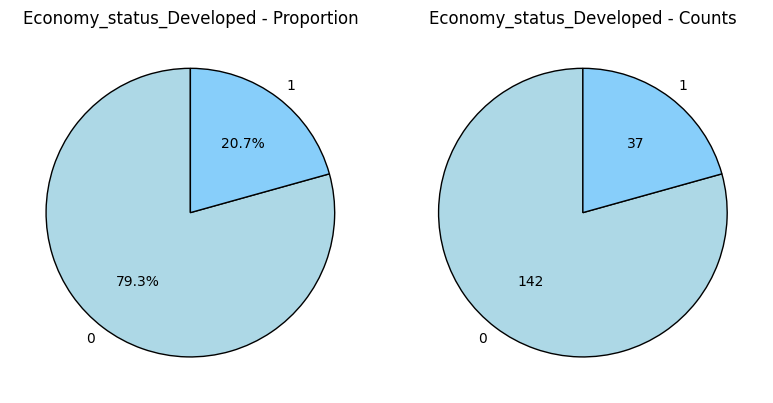

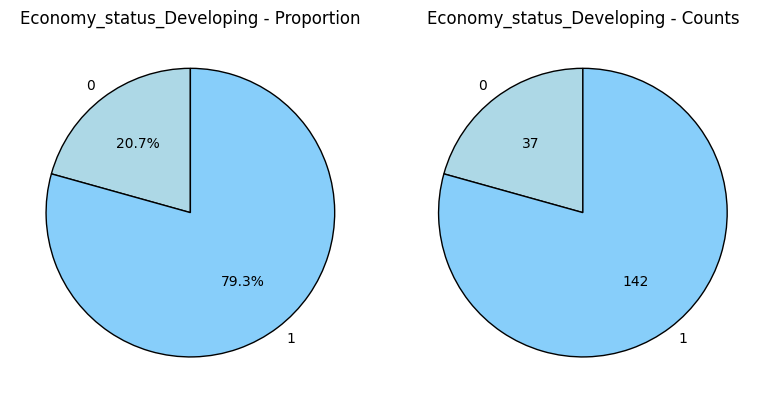

In [5]:
#Define binary columns representing the economic development status of countries. We will visualize these
#to understand the distribution of developed vs. developing countries using side-by-side pie charts
binary_cols = [
    'Economy_status_Developed',
    'Economy_status_Developing'
]

from visualization.explore_binary import plot_binary_distribution
plot_binary_distribution(df, binary_cols = binary_cols)

In [6]:
#Create a subset of the dataset for developed countries
df_developed = df[df['Economy_status_Developed'] == 1]

#Create a subset of the dataset for developing countries
df_developing = df[df['Economy_status_Developing'] == 1]

#These subsets will allow us to compare key health indicators between developed and developing
#countries in subsequent visualizations and analyses.

In [7]:
#Define continuous numeric cols
continuous_numeric_cols = [
    'Infant_deaths',
    'Under_five_deaths',
    'Adult_mortality',
    'Alcohol_consumption',
    'BMI',
    'Incidents_HIV',
    'GDP_per_capita',
    'Population_mln',
    'Schooling',
    'Thinness_ten_nineteen_years',
    'Thinness_five_nine_years',
    'Life_expectancy'
]

#Display the skewness and kurtosis of the selected numeric columns (developed countries)
from eda.check_normality import numeric_skew_kurt
numeric_skew_kurt(df_developed, continuous_numeric_cols)

,Column,Skewness,Kurtosis
0,Infant_deaths,1.166267,1.266345
1,Under_five_deaths,1.292437,1.665371
2,Adult_mortality,1.299533,0.608394
3,Alcohol_consumption,0.042365,2.002419
4,BMI,-1.048592,3.845457
5,Incidents_HIV,2.420218,8.503567
6,GDP_per_capita,1.014928,1.018906
7,Population_mln,4.008710,17.504665
8,Schooling,-0.991532,1.208342
9,Thinness_ten_nineteen_years,0.670217,-0.518133


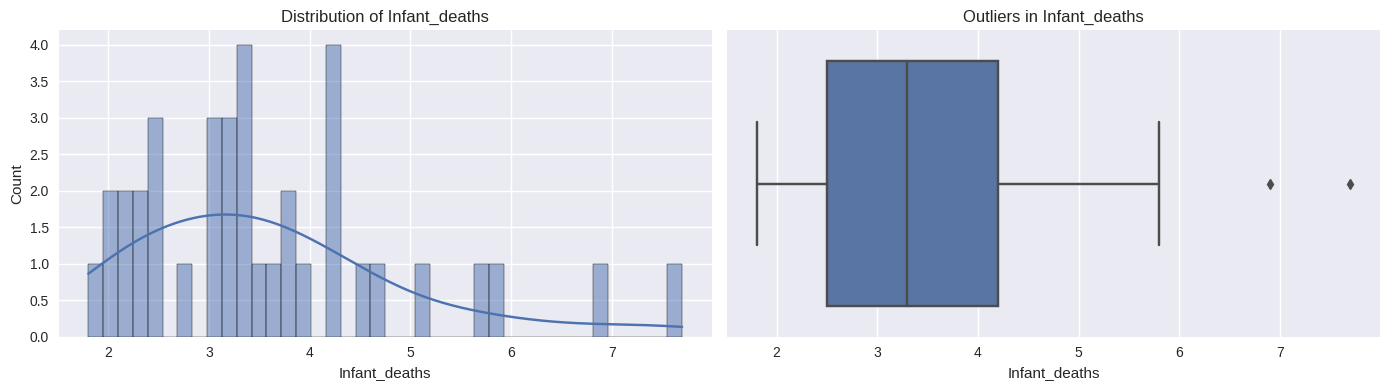

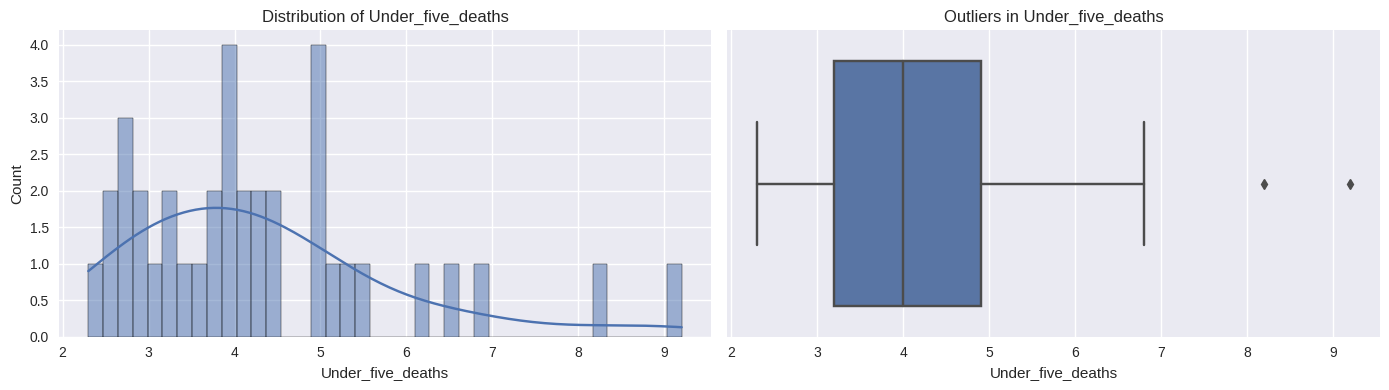

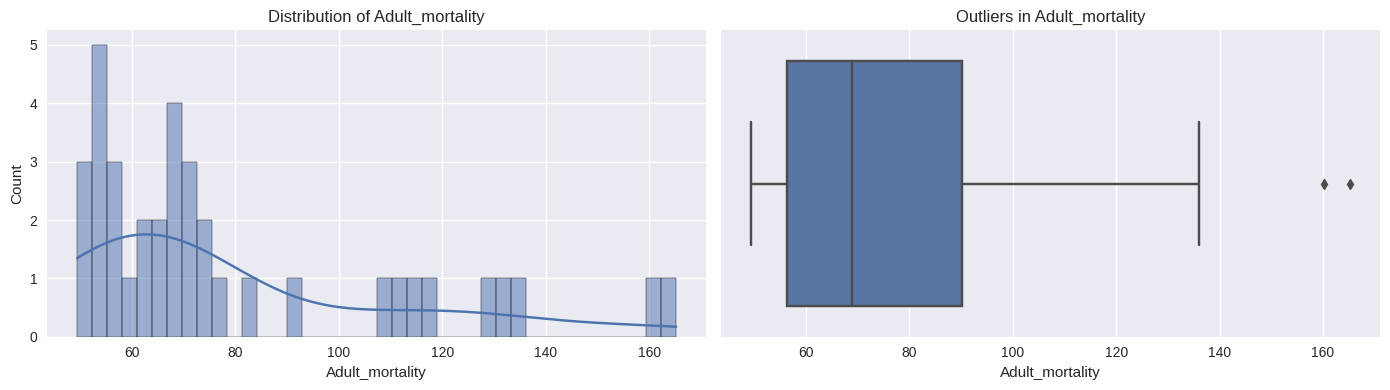

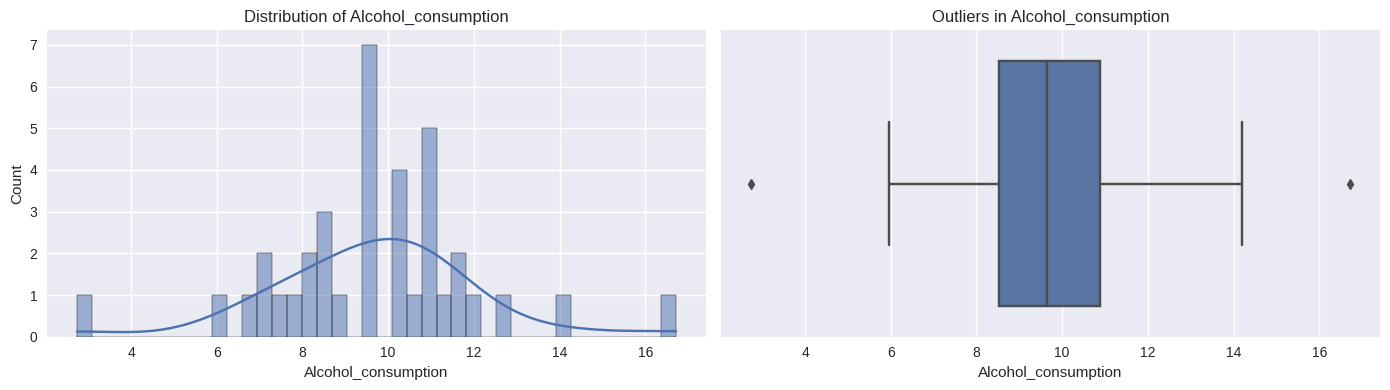

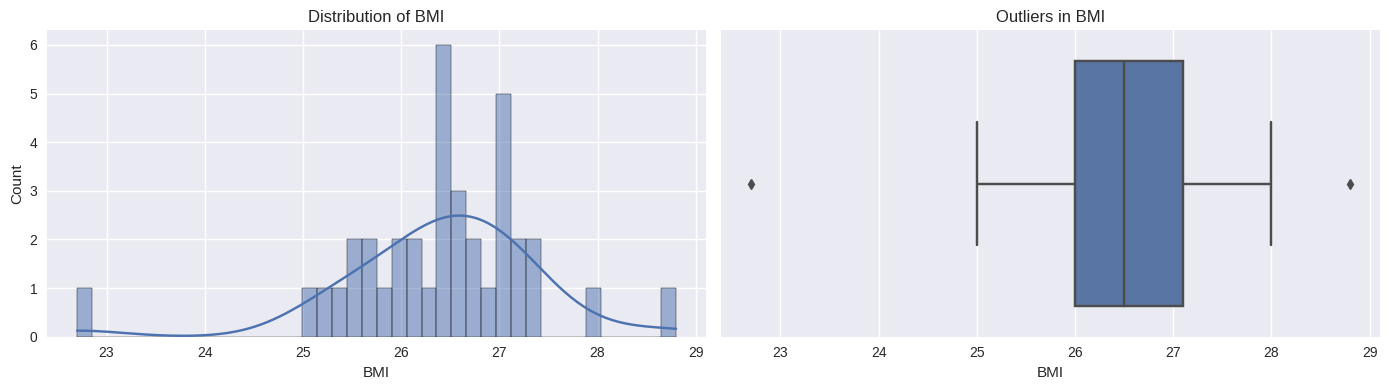

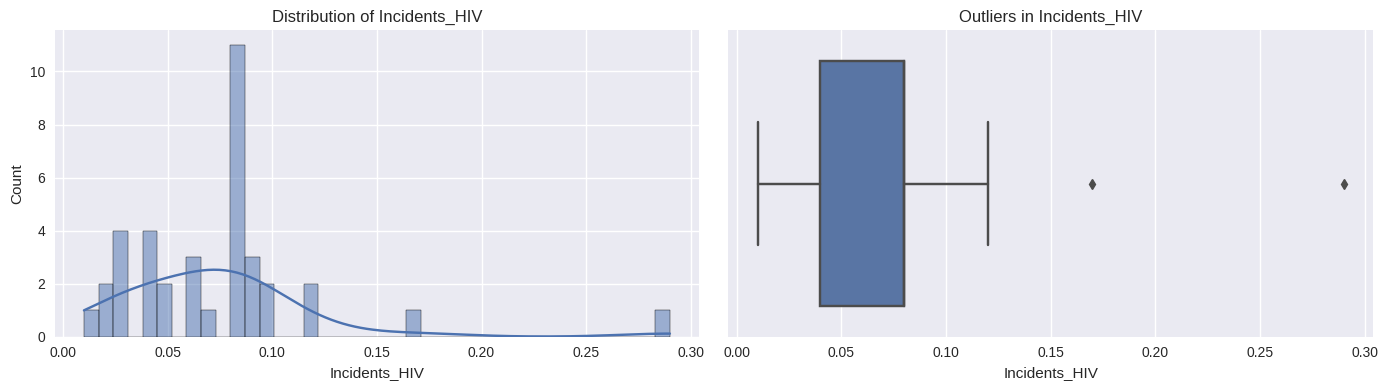

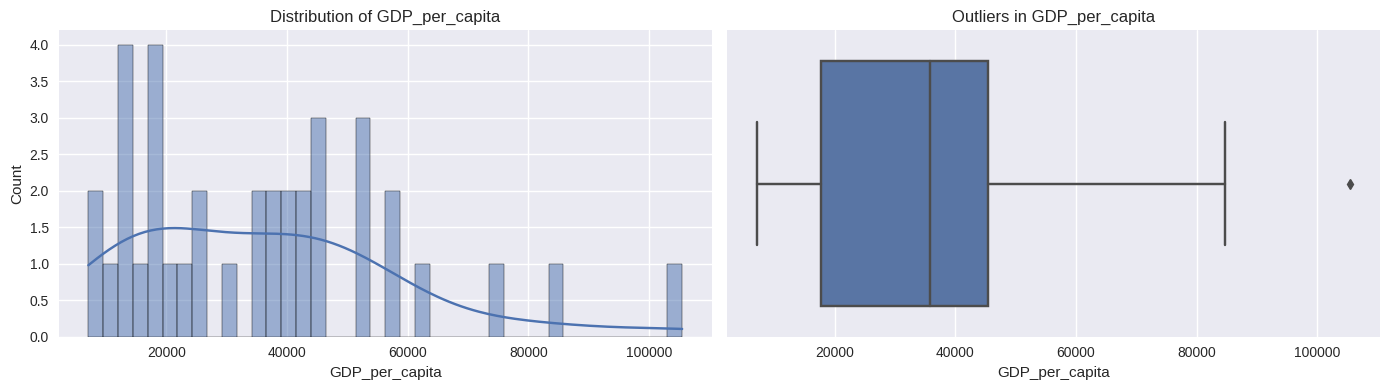

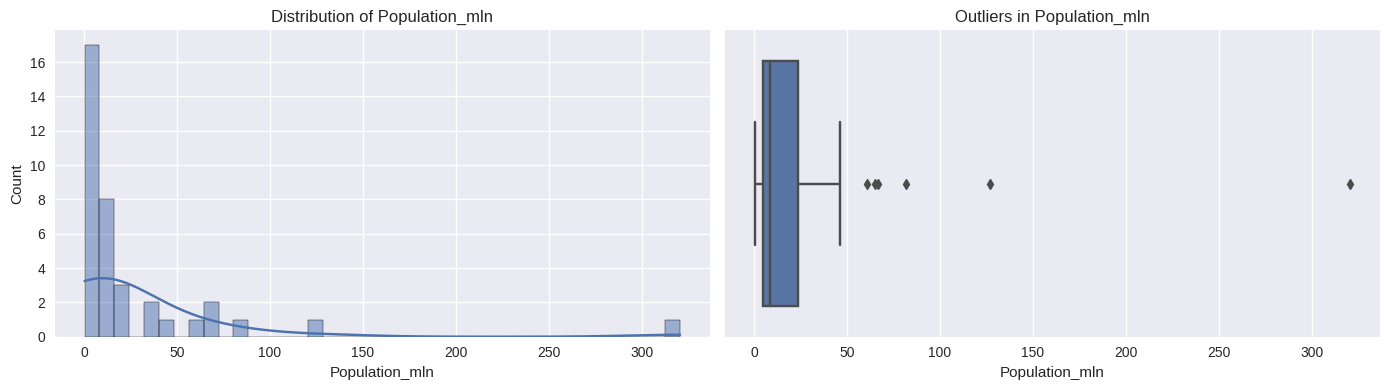

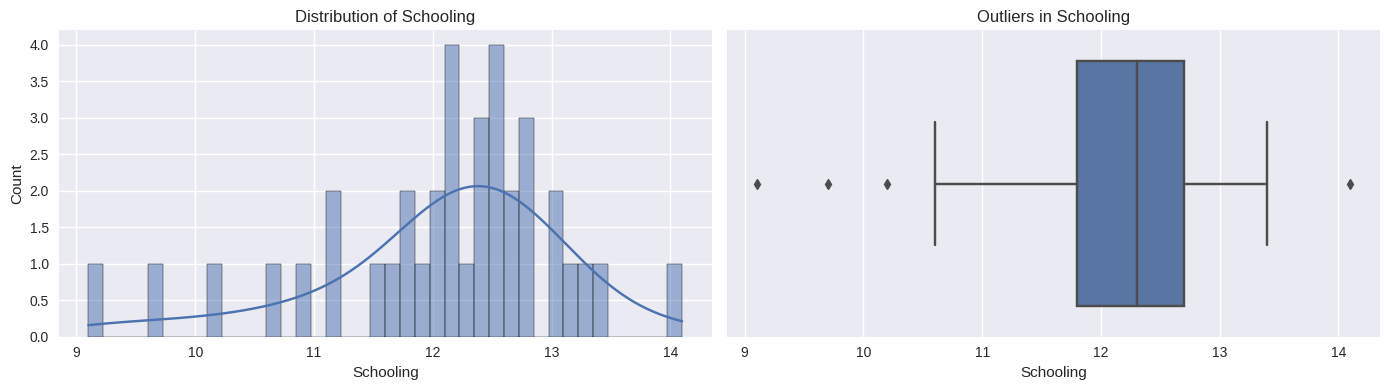

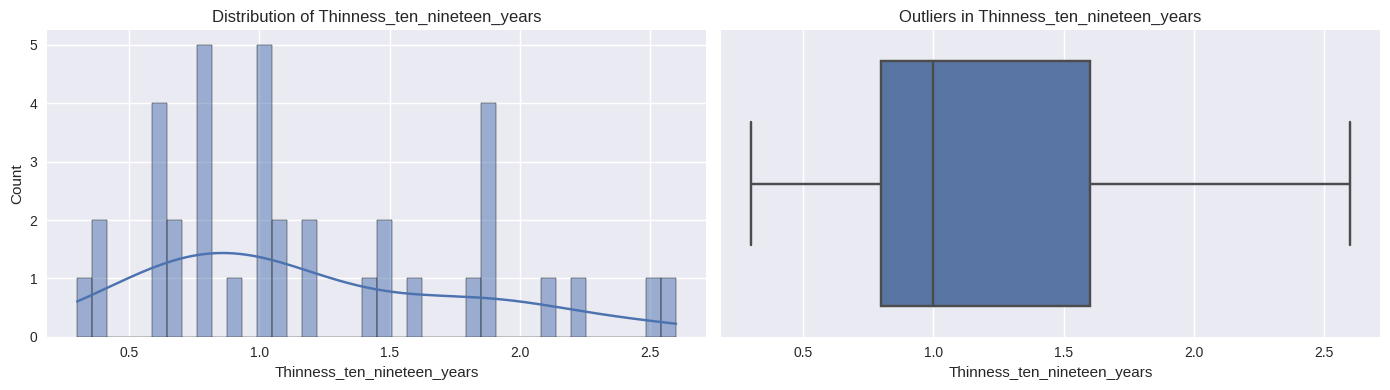

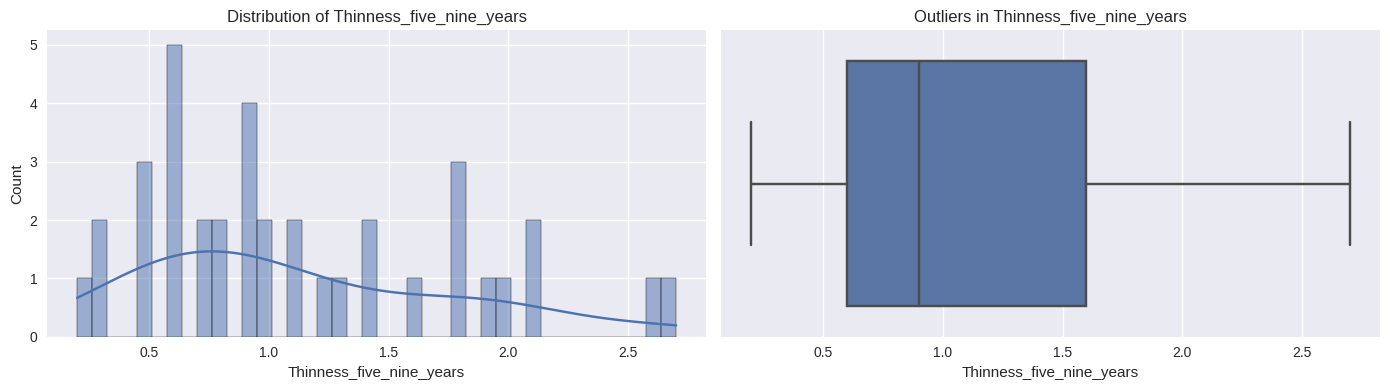

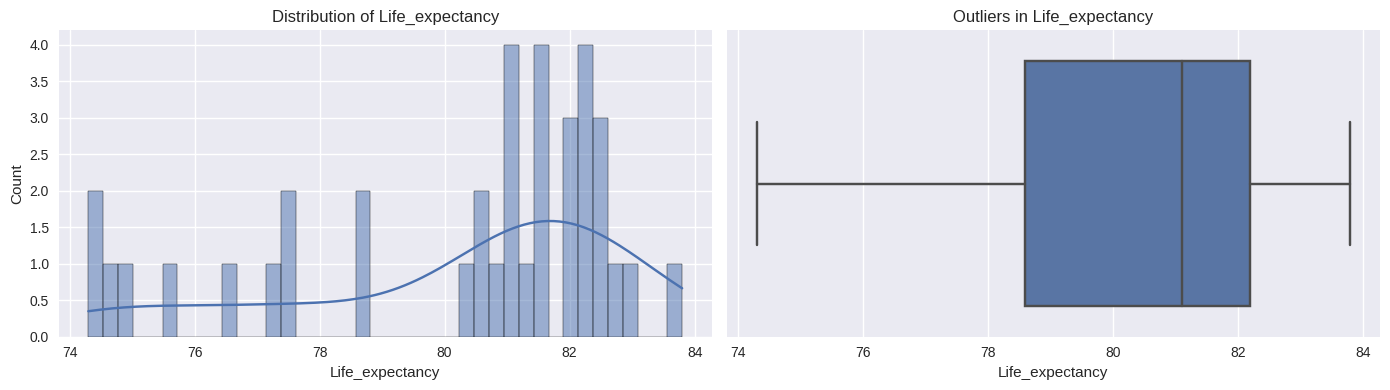

In [8]:
#Plot histograms, KDEs, and boxplots for the specified numeric columns to visualize 
#their distributions and detect outliers
from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df_developed, numeric_cols= continuous_numeric_cols)

In [9]:
#Use a function to identify and count outliers (developed countries)
def detect_outliers_iqr(df: pd.DataFrame, columns: list, factor: float = 1.5) -> dict:
    outlier_counts = {}
    total_outliers = 0
    
    for col in columns:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - factor * IQR
            upper = Q3 + factor * IQR
            outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
            outlier_counts[col] = outlier_count
            total_outliers += outlier_count
    
    outlier_counts['Total_outliers'] = total_outliers
    return outlier_counts

detect_outliers_iqr(df_developed, continuous_numeric_cols)

{'Infant_deaths': 2,
 'Under_five_deaths': 2,
 'Adult_mortality': 2,
 'Alcohol_consumption': 2,
 'BMI': 2,
 'Incidents_HIV': 2,
 'GDP_per_capita': 1,
 'Population_mln': 6,
 'Schooling': 4,
 'Thinness_ten_nineteen_years': 0,
 'Thinness_five_nine_years': 0,
 'Life_expectancy': 0,
 'Total_outliers': 23}

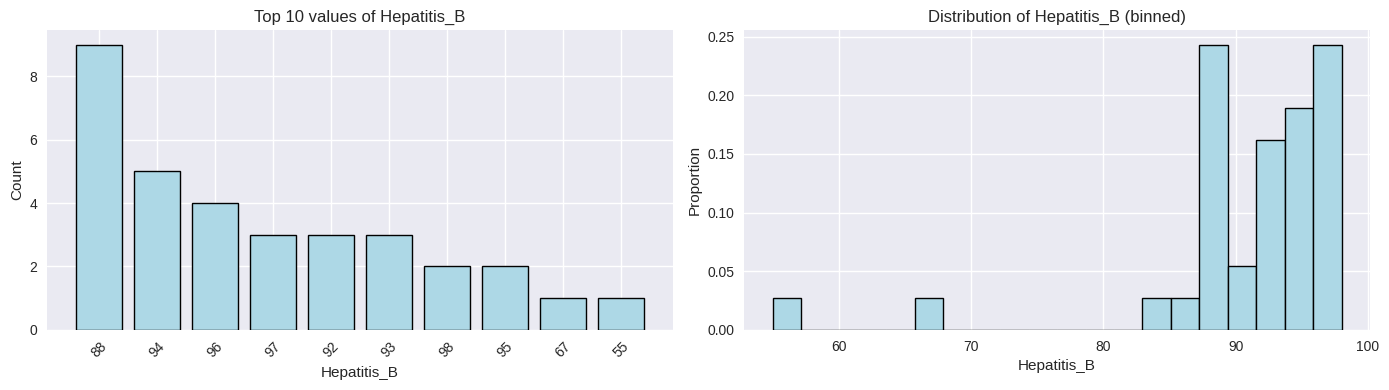

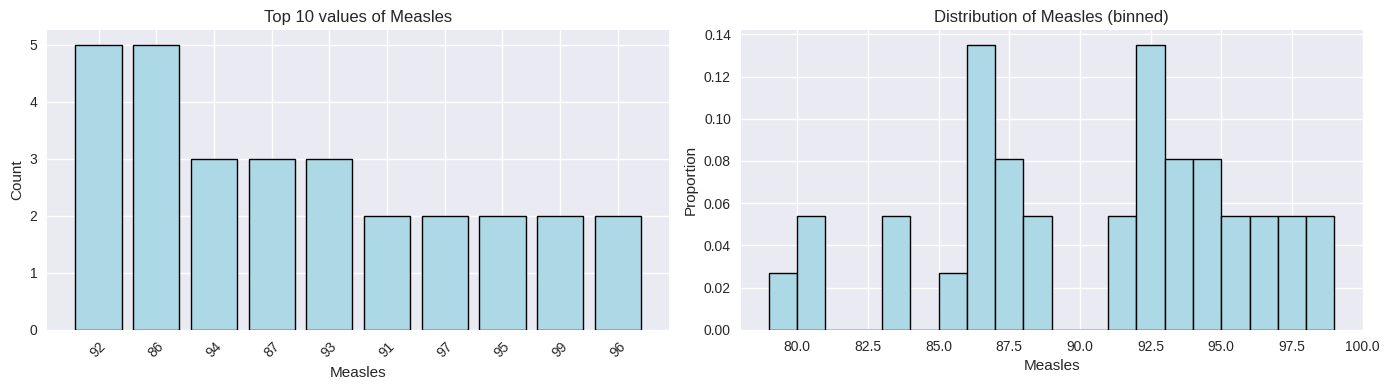

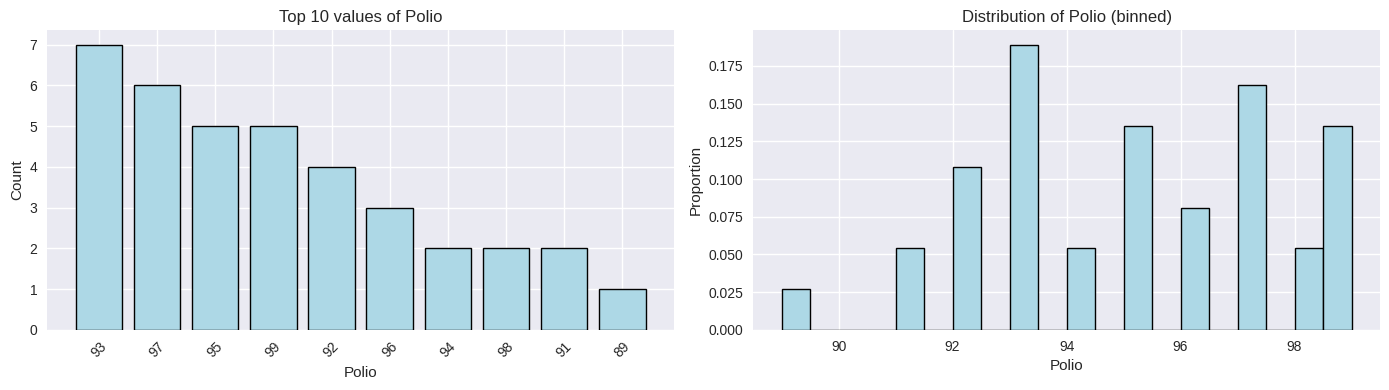

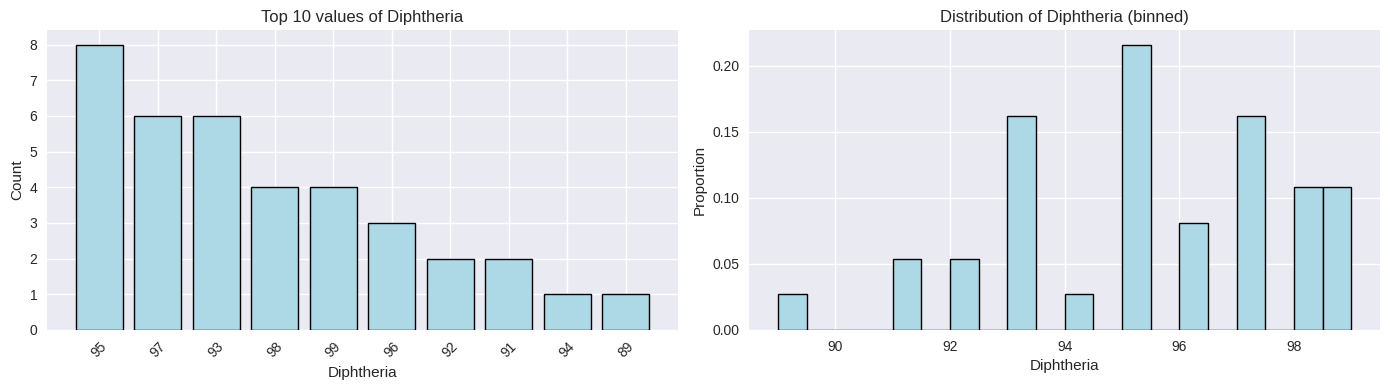

In [10]:
#For discrete variables, we visualize both the top 10 most frequent values (bar plot on the left)
#and the overall binned distribution (histogram on the right) to capture both common categories
#and the general spread of values

#Define discrete numeric cols
discrete_numeric_cols = [
    'Hepatitis_B',
    'Measles',
    'Polio',
    'Diphtheria',
]

from visualization.explore_discrete import plot_discrete_distribution
plot_discrete_distribution(
    df_developed,
    discrete_cols = discrete_numeric_cols,
    top_k = 10,
    bins = 20,
    normalize = True
)

## 1.3-Data Visualization - Univariate (Developing Countries)

In [11]:
#Display the skewness and kurtosis of the selected numeric columns (developing countries)
from eda.check_normality import numeric_skew_kurt
numeric_skew_kurt(df_developing, continuous_numeric_cols)

,Column,Skewness,Kurtosis
0,Infant_deaths,0.960997,0.117576
1,Under_five_deaths,1.158183,0.557036
2,Adult_mortality,0.997759,0.993657
3,Alcohol_consumption,0.520998,-0.940403
4,BMI,0.149639,-0.392076
5,Incidents_HIV,4.765733,27.248010
6,GDP_per_capita,3.578334,15.873793
7,Population_mln,7.440859,56.943440
8,Schooling,-0.182948,-0.978078
9,Thinness_ten_nineteen_years,1.816631,5.000476


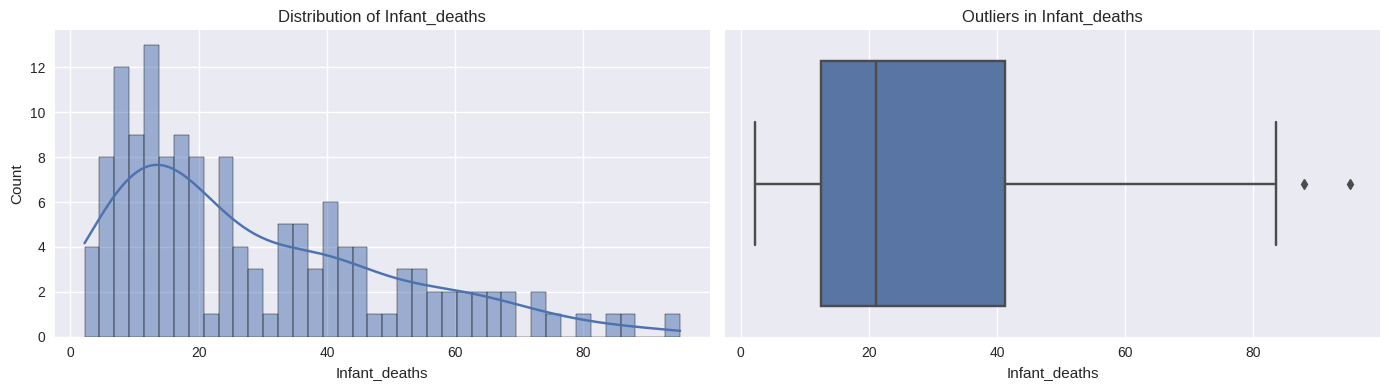

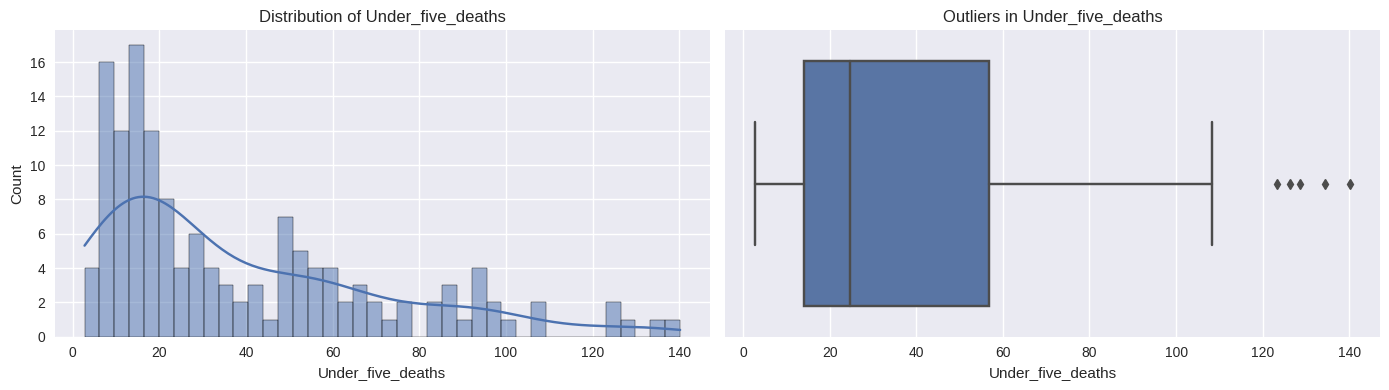

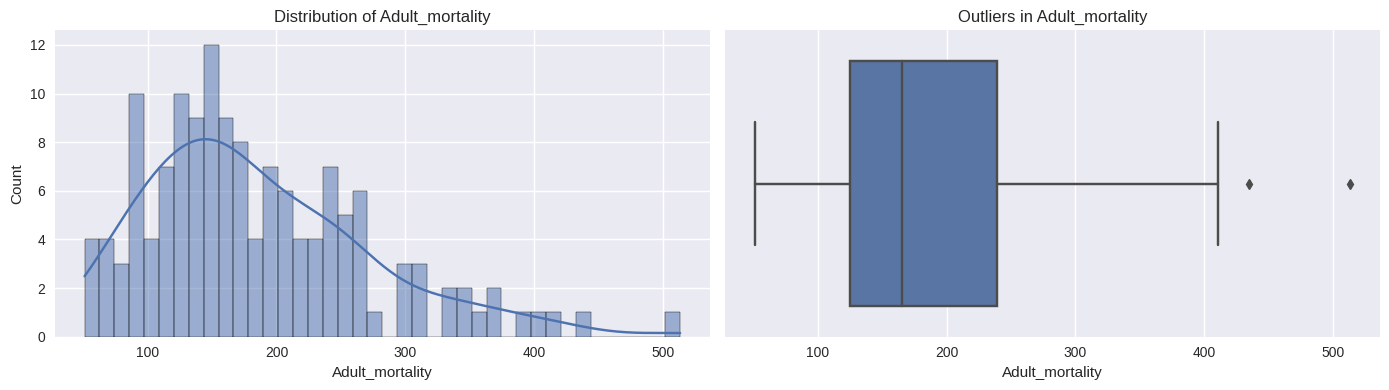

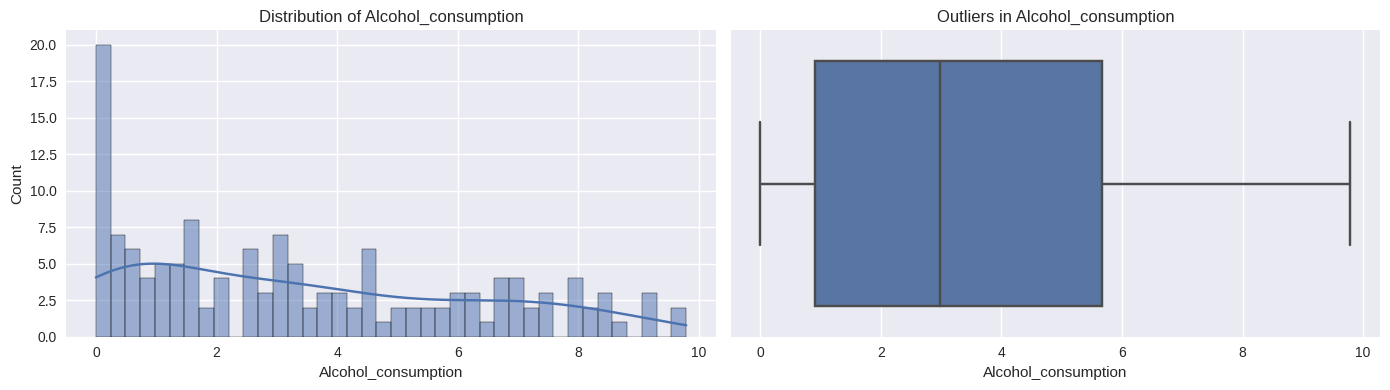

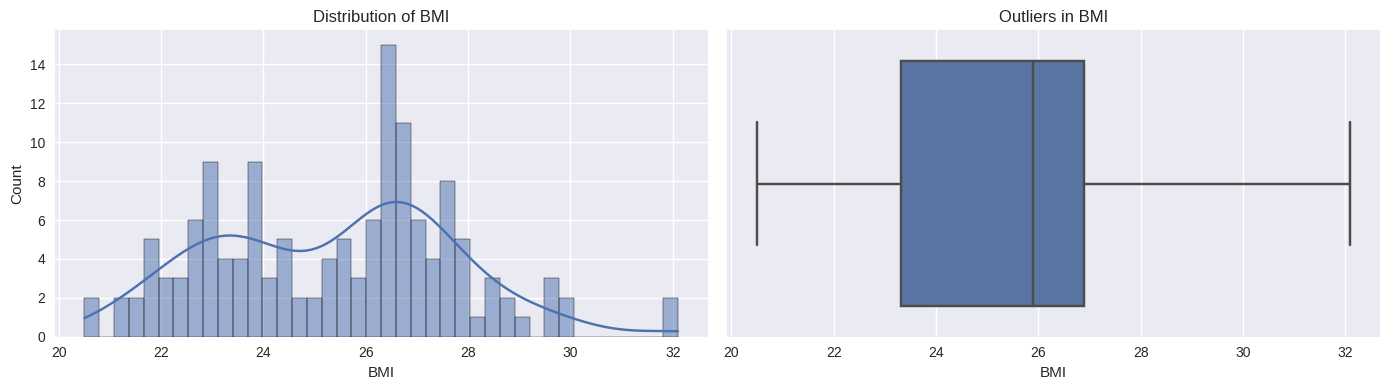

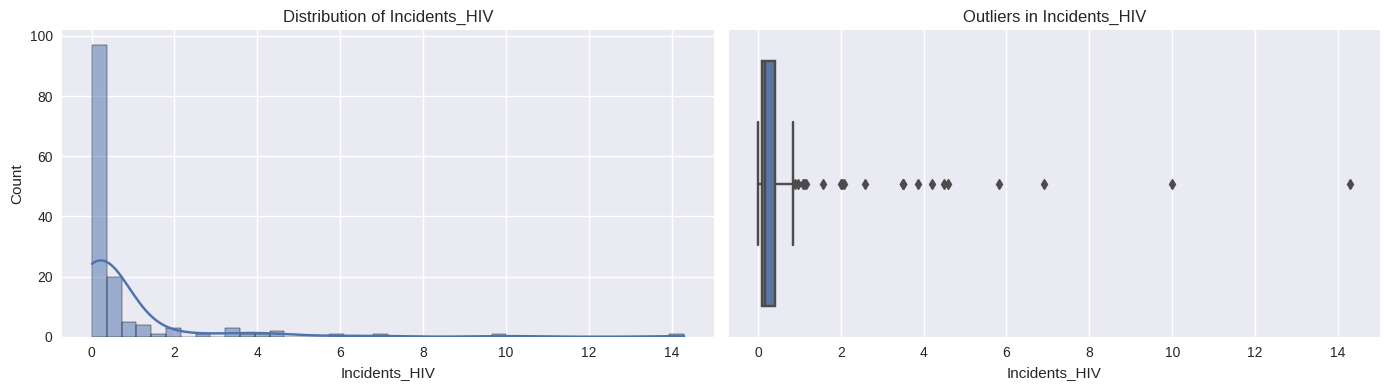

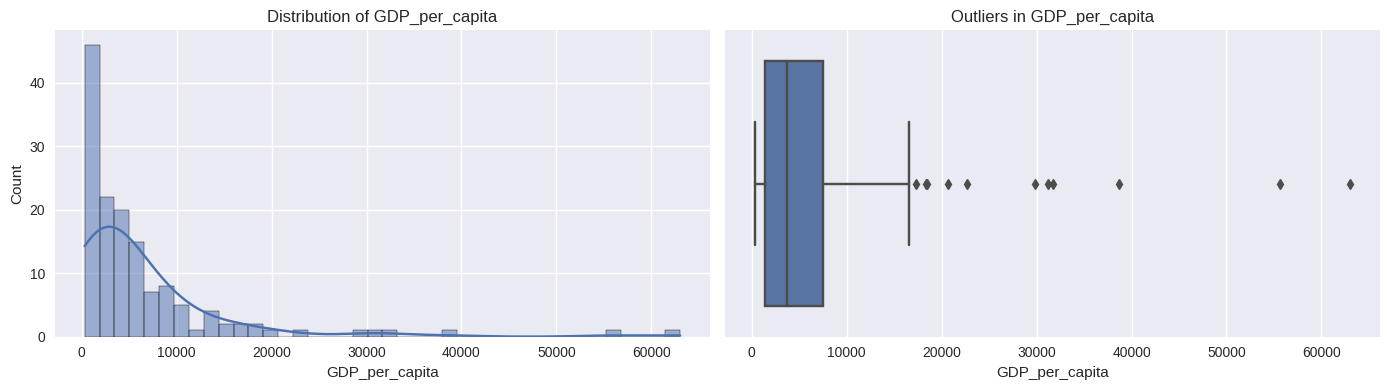

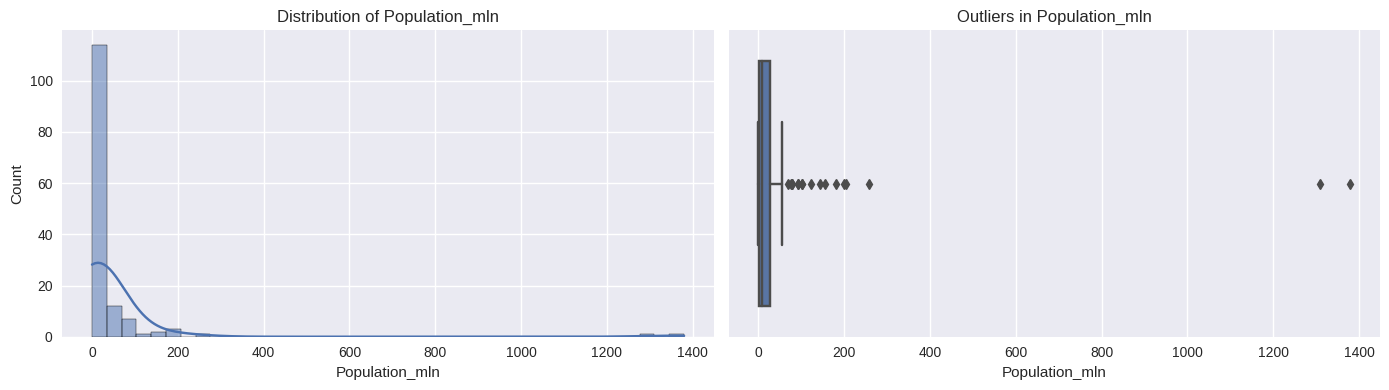

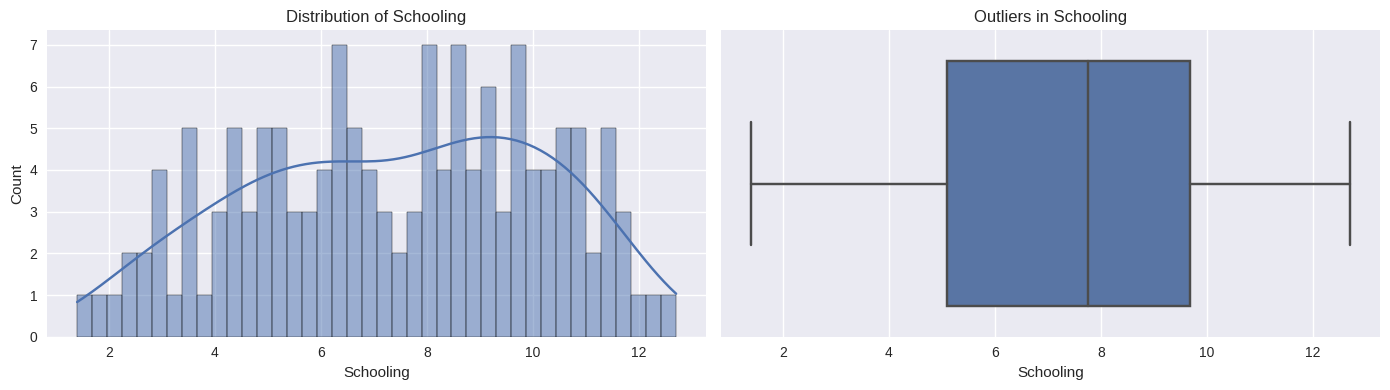

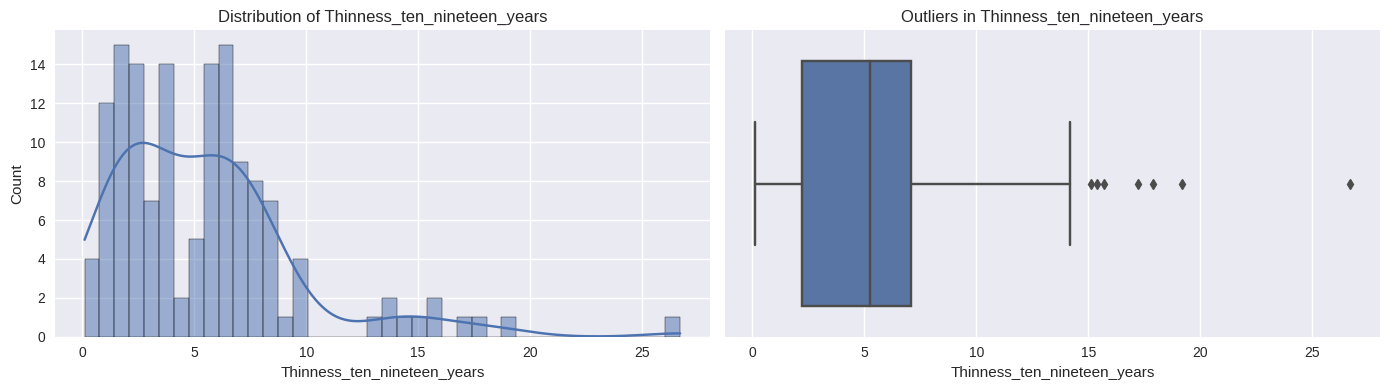

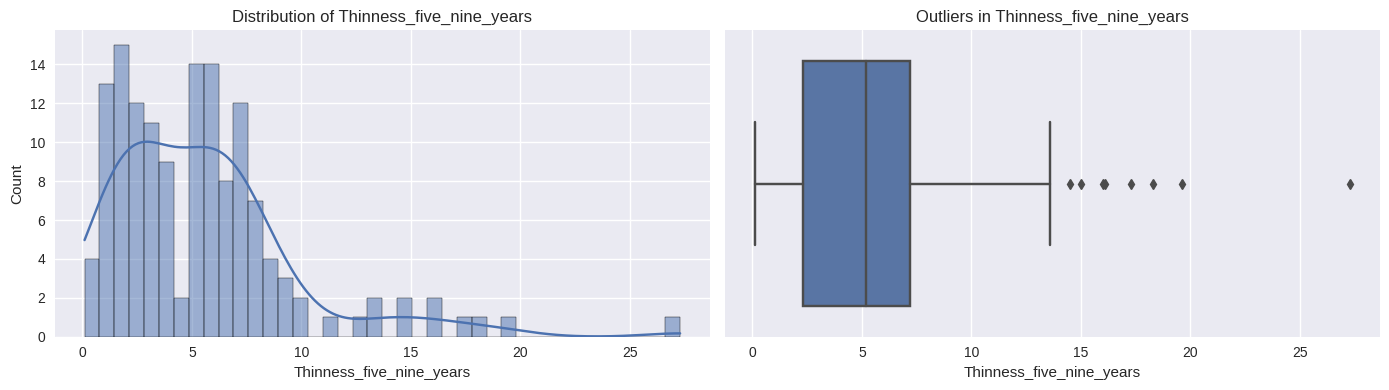

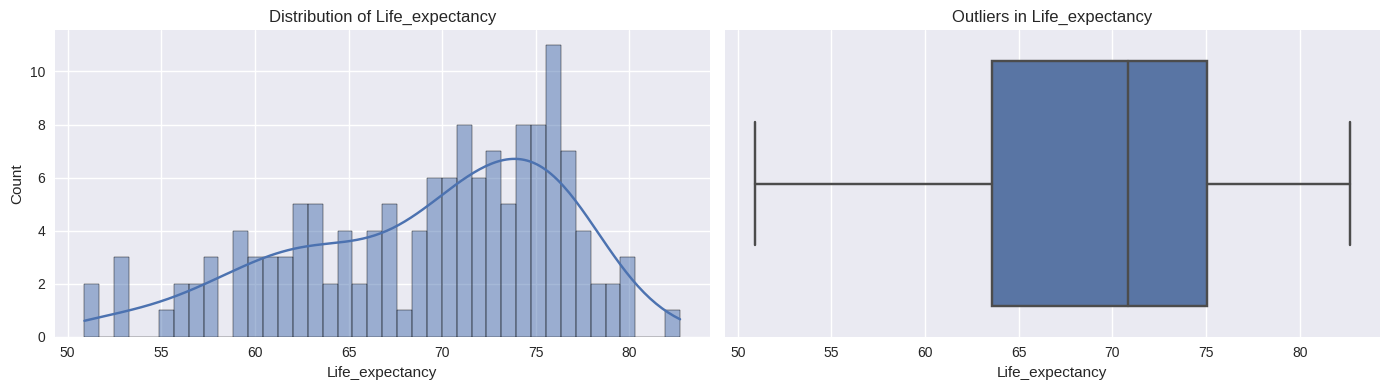

In [12]:
#Plot histograms, KDEs, and boxplots for the specified numeric columns to visualize 
#their distributions and detect outliers
from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df_developing, numeric_cols= continuous_numeric_cols)

In [13]:
#Use a function to identify and count outliers (developing countries)
def detect_outliers_iqr(df: pd.DataFrame, columns: list, factor: float = 1.5) -> dict:
    outlier_counts = {}
    total_outliers = 0
    
    for col in columns:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - factor * IQR
            upper = Q3 + factor * IQR
            outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
            outlier_counts[col] = outlier_count
            total_outliers += outlier_count
    
    outlier_counts['Total_outliers'] = total_outliers
    return outlier_counts

detect_outliers_iqr(df_developing, continuous_numeric_cols)

{'Infant_deaths': 2,
 'Under_five_deaths': 5,
 'Adult_mortality': 2,
 'Alcohol_consumption': 0,
 'BMI': 0,
 'Incidents_HIV': 22,
 'GDP_per_capita': 11,
 'Population_mln': 17,
 'Schooling': 0,
 'Thinness_ten_nineteen_years': 7,
 'Thinness_five_nine_years': 8,
 'Life_expectancy': 0,
 'Total_outliers': 74}

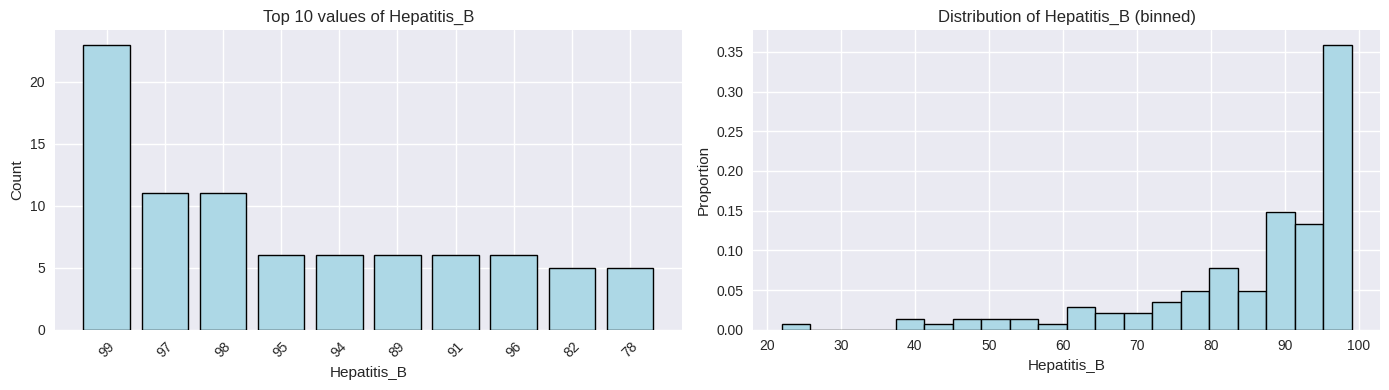

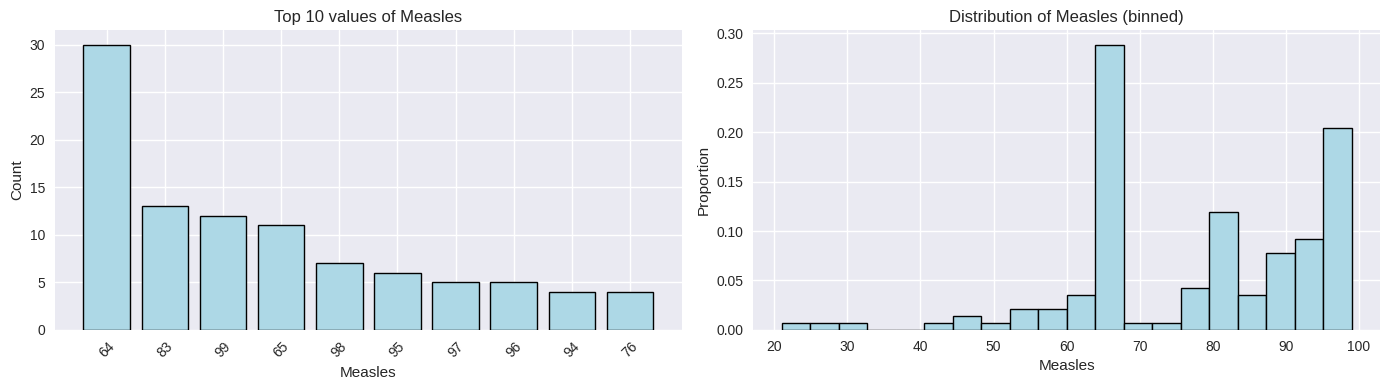

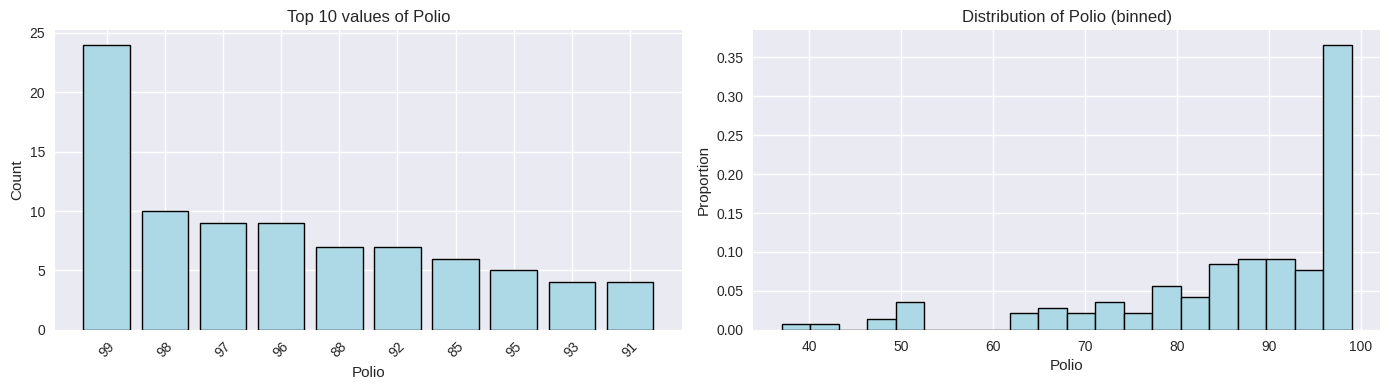

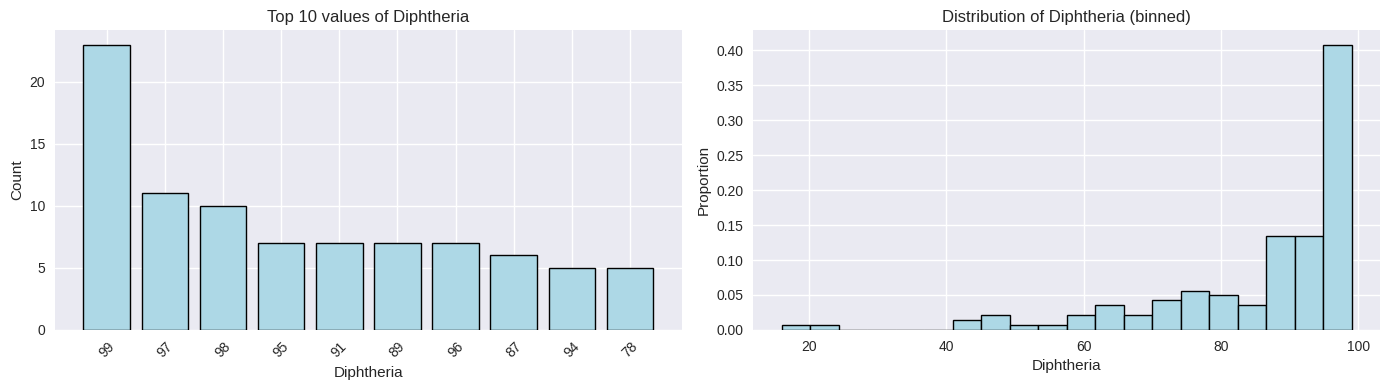

In [14]:
#For discrete variables, we visualize both the top 10 most frequent values (bar plot on the left)
#and the overall binned distribution (histogram on the right) to capture both common categories
#and the general spread of values
from visualization.explore_discrete import plot_discrete_distribution
plot_discrete_distribution(
    df_developing,
    discrete_cols = discrete_numeric_cols,
    top_k = 10,
    bins = 20,
    normalize = True
)

**Key Takeaways**

**Life Expectancy**: Higher in developed countries vs. developing.  

**Mortality**: Infant, under-five, and adult mortality are substantially lower in developed countries.  

**Nutrition & BMI**: Developed countries show higher BMI and lower prevalence of thinness.  

**Alcohol Consumption**: Higher in developed countries.  

**Vaccination Coverage**: Generally high in developed countries; most values near maximum (Hepatitis B, Polio, Diphtheria, Measles).  

**Economic & Education Indicators**: GDP per capita and schooling years are much higher in developed countries.  

**Outliers & Distribution**: Detected outliers are statistical in nature but remain plausible and meaningful from a real-world perspective. Developing countries show more skewed distributions and extreme values (HIV incidence, population size, GDP).  

## 1.4-Data Visualization - Multivariate

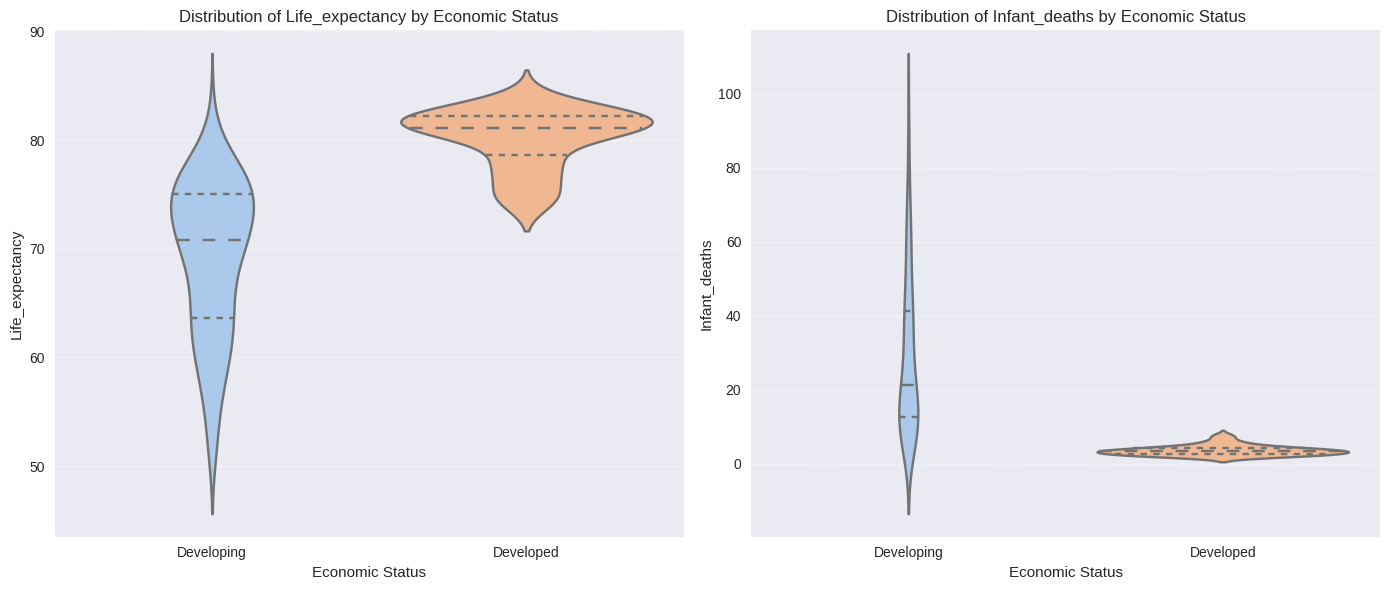

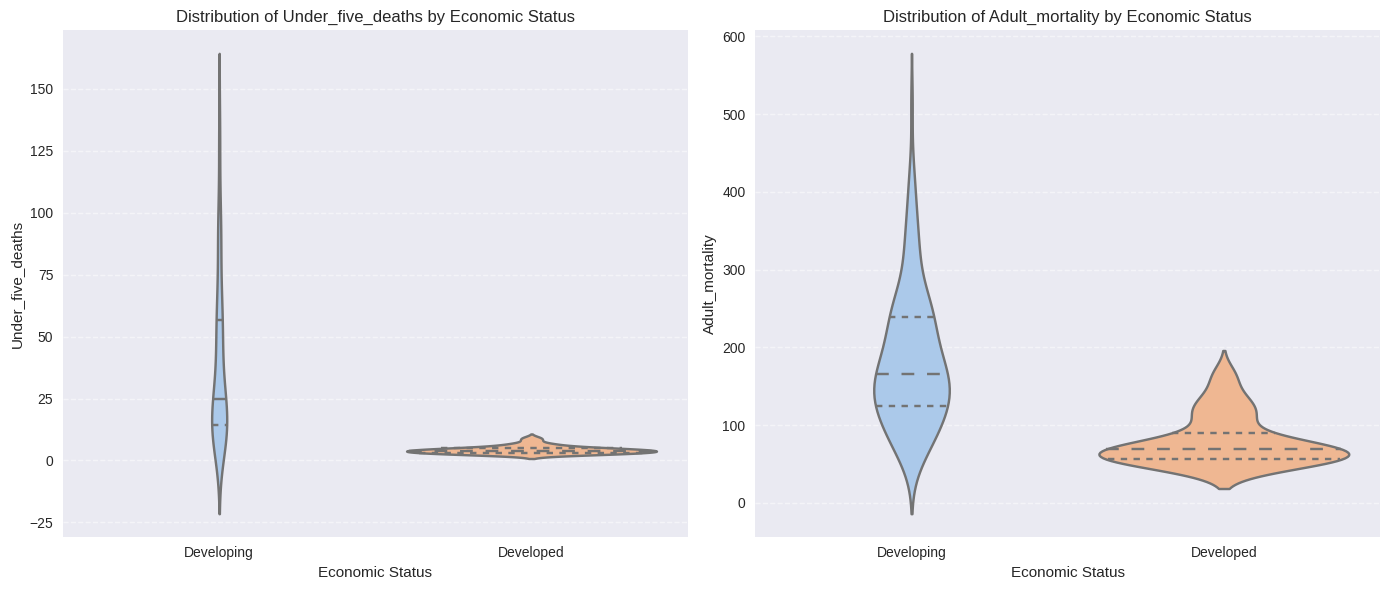

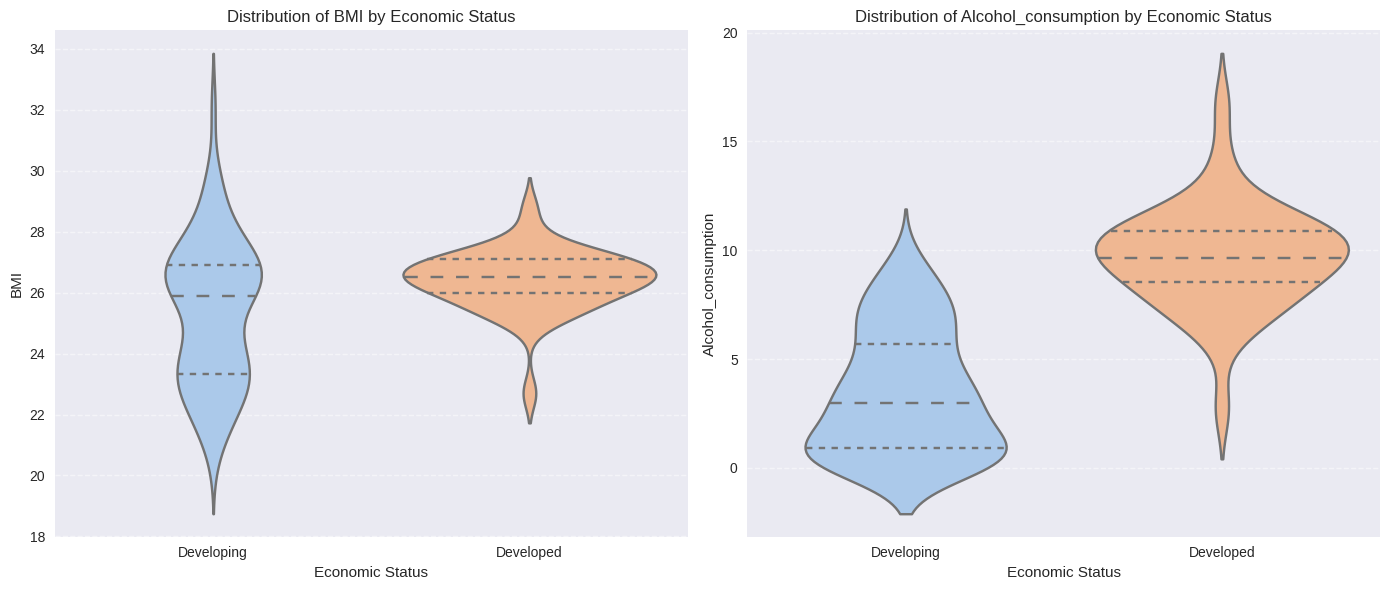

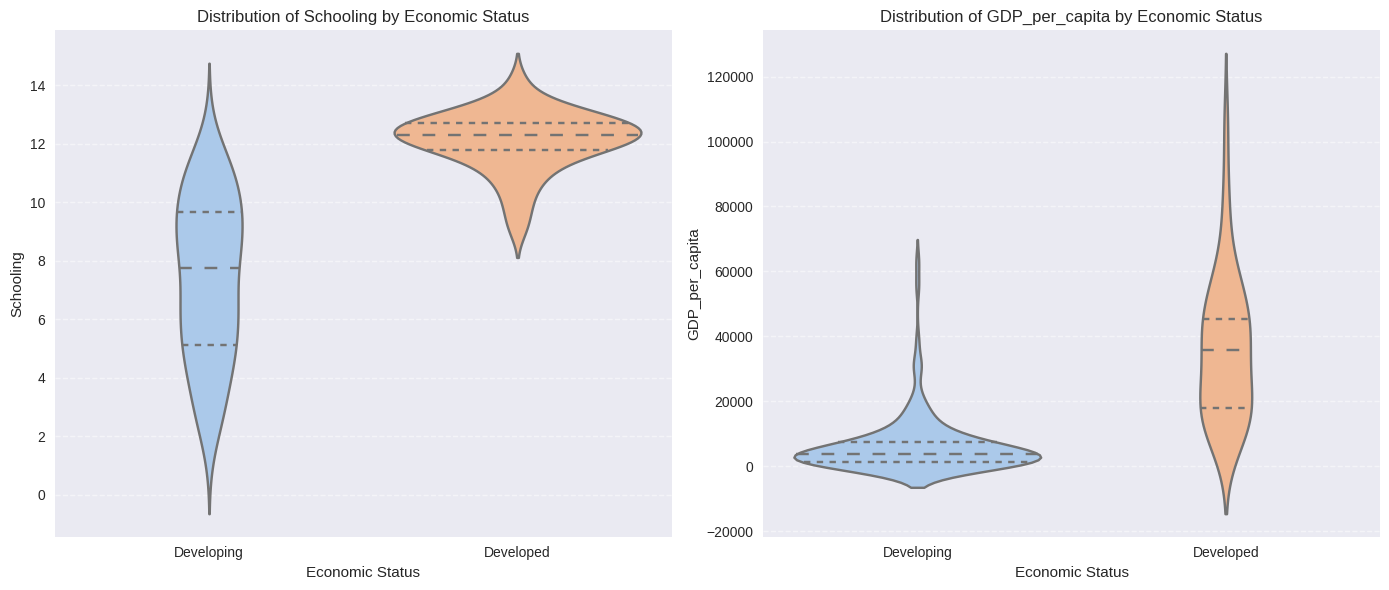

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select key continuous variables that capture major health, nutrition, mortality, and socioeconomic 
# indicators. These variables are relevant to the research question on how economic development
# impacts health outcomes
relevant_cols = [
    'Life_expectancy',      #Overall health outcome
    'Infant_deaths',        #Child health and mortality
    'Under_five_deaths',    #Early childhood health
    'Adult_mortality',      #Mortality in working-age population
    'BMI',                  #Nutrition and health status
    'Alcohol_consumption',  #Lifestyle-related health factor
    'Schooling',            #Education as a socioeconomic indicator
    'GDP_per_capita'        #Economic development indicator
]

#Create a single column representing economic status for easier plotting
df['Economic_status'] = df['Economy_status_Developed'].replace({1: 'Developed', 0: 'Developing'})

#Plot 2 violin plots per row
for i in range(0, len(relevant_cols), 2):
    cols_pair = relevant_cols[i:i+2]  # take 2 columns at a time
    fig, axes = plt.subplots(1, len(cols_pair), figsize = (14,6), sharey = False)
    
    if len(cols_pair) == 1: 
        axes = [axes]
    
    for ax, col in zip(axes, cols_pair):
        #Violin plot: chosen because it shows the full distribution of the data, including density,
        #median, and quartiles, allowing visual comparison of distributions between developed
        #and developing countries
        sns.violinplot(
            data=df,
            x='Economic_status',
            y=col,
            palette='pastel',
            inner='quartile',
            ax=ax
        )
        #Set plot title and axis labels
        ax.set_title(f'Distribution of {col} by Economic Status')
        ax.set_xlabel('Economic Status')
        ax.set_ylabel(col)
        #Add grid lines for easier reading
        ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

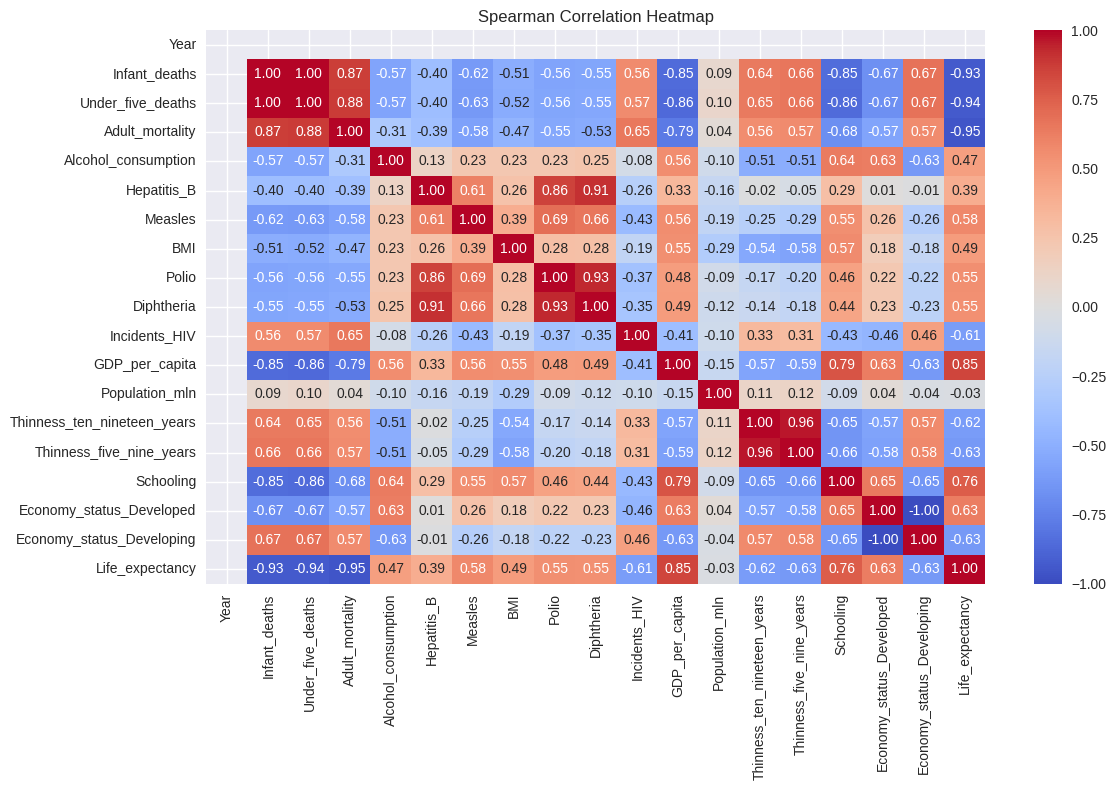

In [16]:
#Compute and visualize the correlation structure of numerical variables. These correlations are
#descriptive and do not imply causality. Spearman correlation is used because it captures monotonic
#relationships and is more robust to non-normal distributions and outliers than Pearson.
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(
    df,
    numeric_cols = None,
    method = 'spearman',
    figsize = (12,8),
    cmap = 'coolwarm',
    annot = True,
    fmt = ".2f"
)

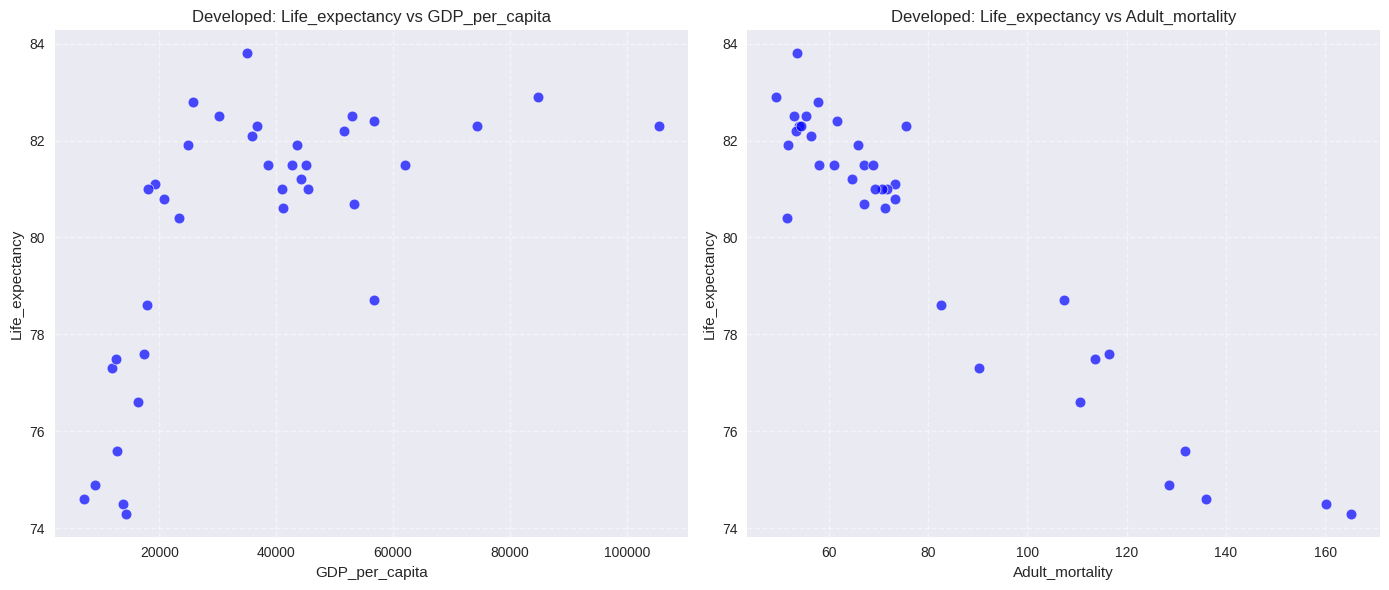

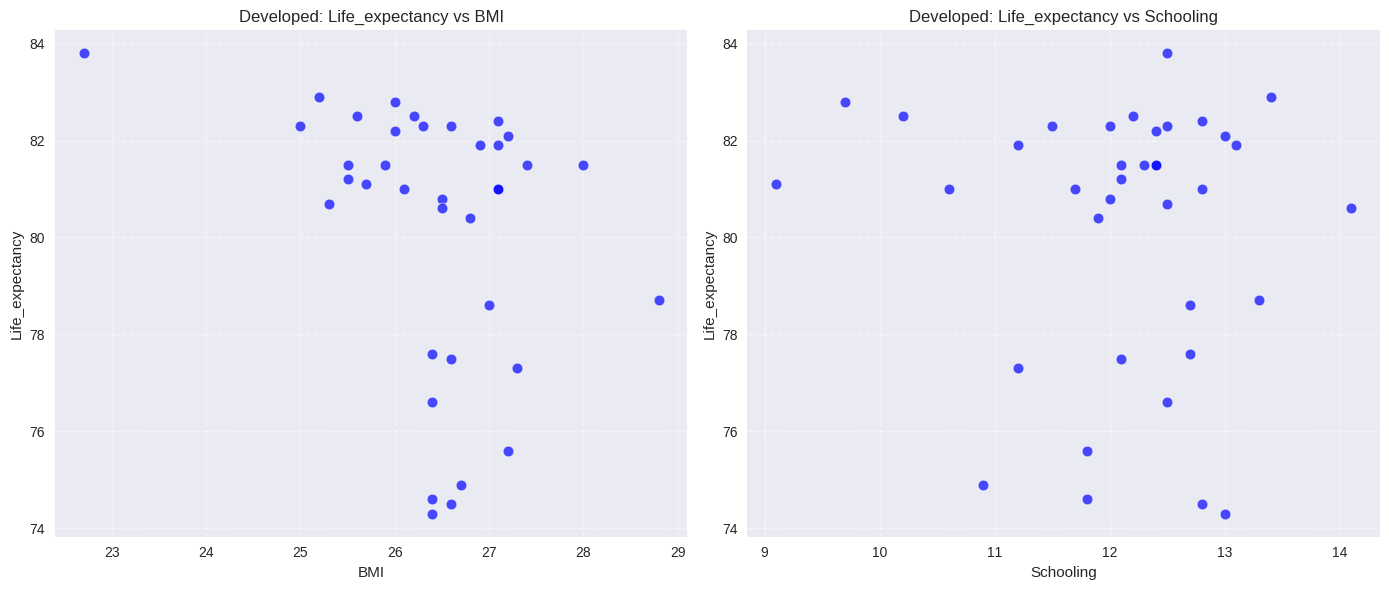

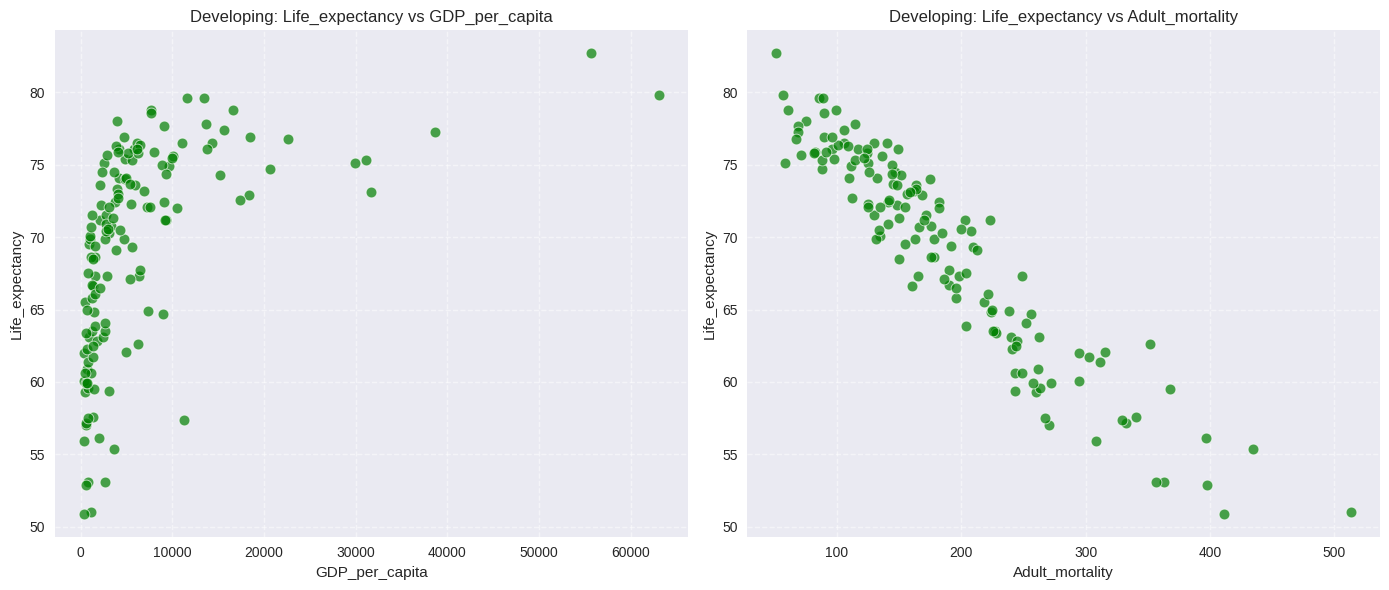

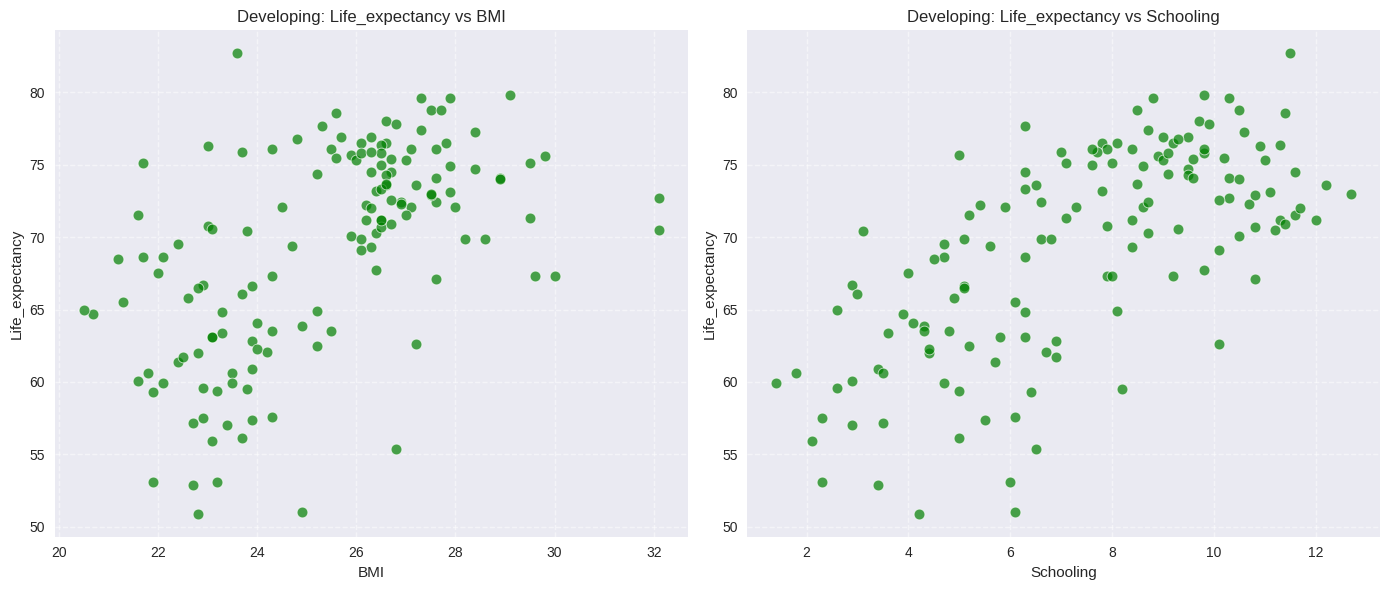

In [17]:
#Define key variables for scatterplots. We choose variables that are closely related to our main
#research question: How economic development impacts health outcomes like life expectancy in 2015.
scatter_vars = [
    ('GDP_per_capita', 'Life_expectancy'),      #Economic indicator vs health outcome
    ('Adult_mortality', 'Life_expectancy'),     #Mortality patterns vs life expectancy
    ('BMI', 'Life_expectancy'),                 #Nutrition/health status vs life expectancy
    ('Schooling', 'Life_expectancy')            #Education vs life expectancy
]

#Separate datasets for developed and developing countries. This allows us to directly compare
#trends between different economic groups
df_dev = df[df['Economy_status_Developed'] == 1]
df_developing = df[df['Economy_status_Developed'] == 0]

#Plot scatterplots 2 per row for Developed countries
for i in range(0, len(scatter_vars), 2):
    vars_pair = scatter_vars[i:i+2]
    fig, axes = plt.subplots(1, len(vars_pair), figsize=(14,6), sharey=False)
    
    if len(vars_pair) == 1:
        axes = [axes]

    for ax, (x_var, y_var) in zip(axes, vars_pair):
        #Scatterplot for Developed countries (blue)
        #Separate plot emphasizes trends within this group
        sns.scatterplot(
            data=df_dev,
            x=x_var,
            y=y_var,
            color='blue',
            alpha=0.7,
            s=60,
            ax=ax
        )
        ax.set_xlabel(x_var)
        ax.set_ylabel(y_var)
        ax.set_title(f'Developed: {y_var} vs {x_var}')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

#Plot scatterplots 2 per row for Developing countries
for i in range(0, len(scatter_vars), 2):
    vars_pair = scatter_vars[i:i+2]
    fig, axes = plt.subplots(1, len(vars_pair), figsize=(14,6), sharey=False)
    
    if len(vars_pair) == 1:
        axes = [axes]

    for ax, (x_var, y_var) in zip(axes, vars_pair):
        #Scatterplot for Developing countries (green)
        #Separate plot emphasizes trends within this group
        sns.scatterplot(
            data=df_developing,
            x=x_var,
            y=y_var,
            color='green',
            alpha=0.7,
            s=60,
            ax=ax
        )
        ax.set_xlabel(x_var)
        ax.set_ylabel(y_var)
        ax.set_title(f'Developing: {y_var} vs {x_var}')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

**Key Takeaways**

- **Life Expectancy & Mortality vs Development:** The negative association between adult mortality and life expectancy is visually stronger in developing countries, highlighting how mortality patterns more severely constrain longevity in lower-income settings.

- **BMI & Life Expectancy:** Developed countries exhibit higher BMI levels with relatively stable life expectancy, while in developing countries BMI is lower but shows a clearer positive association with life expectancy.

- **Schooling & Life Expectancy:** Education is strongly associated with life expectancy in both economic groups. The visual relationship appears steeper in developing countries, suggesting larger marginal gains in health outcomes where educational attainment is lower.

- **Correlation Patterns:** Descriptive Spearman correlations indicate that the strength of associations between socioeconomic and health variables differs by economic status. These correlations are descriptive and do not imply causal relationships.

